# Task 1
# Formulate Research Question


### Research Question
**“Can machine learning models predict the daily Air Quality Index (AQI) of Indian cities between 2015–2020 using pollutant concentration data?”**

### Objective
The objective of this analysis is to build a **Multiple Linear Regression** model that quantifies the relationship between major pollutants and the overall Air Quality Index. This will help identify which specific pollutants are the most significant contributors to poor air quality in urban India.

### Variables
* **Dependent Variable ($y$):** `AQI` 
* **Independent Variables ($x$):**
    1. `PM2.5`: Fine particulate matter.
    2. `PM10`: Coarse particulate matter.
    3. `NO2`: Nitrogen dioxide concentration.

# Task 2
# Data Validation and Cleaning


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,mean_squared_error, r2_score
print("Libraries imported successfully.")



Libraries imported successfully.


# 
Inspect dataset structure and data types

In [3]:
df=pd.read_csv('city_day.csv')
df


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [8]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [ ]:
# 1. Drop rows where  (AQI) is missing
df = df.dropna(subset=['AQI'])

# 2. Fill the PREDICTORS (X) with the mean
df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].mean())
df['PM10'] = df['PM10'].fillna(df['PM10'].mean())
df['NO2'] = df['NO2'].fillna(df['NO2'].mean())

# 3. Verify
print(df[['AQI', 'PM2.5', 'PM10', 'NO2']].isnull().sum())

AQI      0
PM2.5    0
PM10     0
NO2      0
dtype: int64


In [18]:
df.duplicated().sum()

np.int64(0)

# Summarize Findings

After Cleaning the Data set i discovered that there are many missing values and duplicate data , there are 29531 rows and  16 columns at the begining , however i drop the values or data that i will not use as variables after cleaning the missing values of AQI is 4681 while the other variables are 0.So i drop these rows to ensure the model has a valid ground truth .

# Task 3

# Exploratory Data Analysis (EDA)

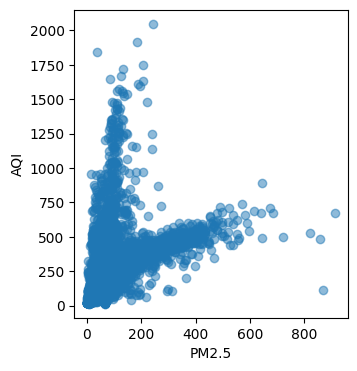

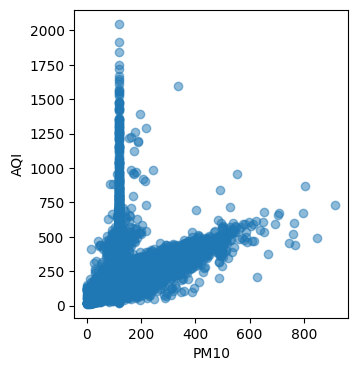

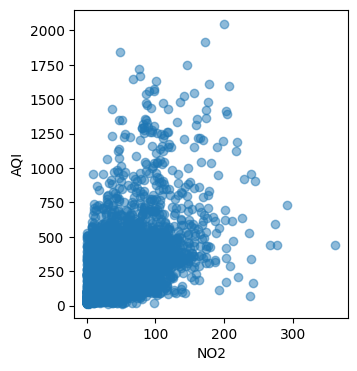

In [20]:
# A Scatter

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(df['PM2.5'], df['AQI'], alpha=0.5)
plt.xlabel('PM2.5')
plt.ylabel('AQI')


plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 2)
plt.scatter(df['PM10'], df['AQI'], alpha=0.5)
plt.xlabel('PM10')
plt.ylabel('AQI')


plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 3)
plt.scatter(df['NO2'], df['AQI'], alpha=0.5)
plt.xlabel('NO2')
plt.ylabel('AQI')

plt.show()

# Explanation of Vizualization

Based on the EDA visualizations, $PM_{2.5}$ is the primary contributor to AQI. This is visually evident in the scatter plot, which shows the most defined linear trend, and mathematically confirmed by the Correlation Heatmap with the highest coefficient of 0.65. While $PM_{10}$ and $NO_2$ also show positive trends, they have more variance (scatter) compared to $PM_{2.5}$

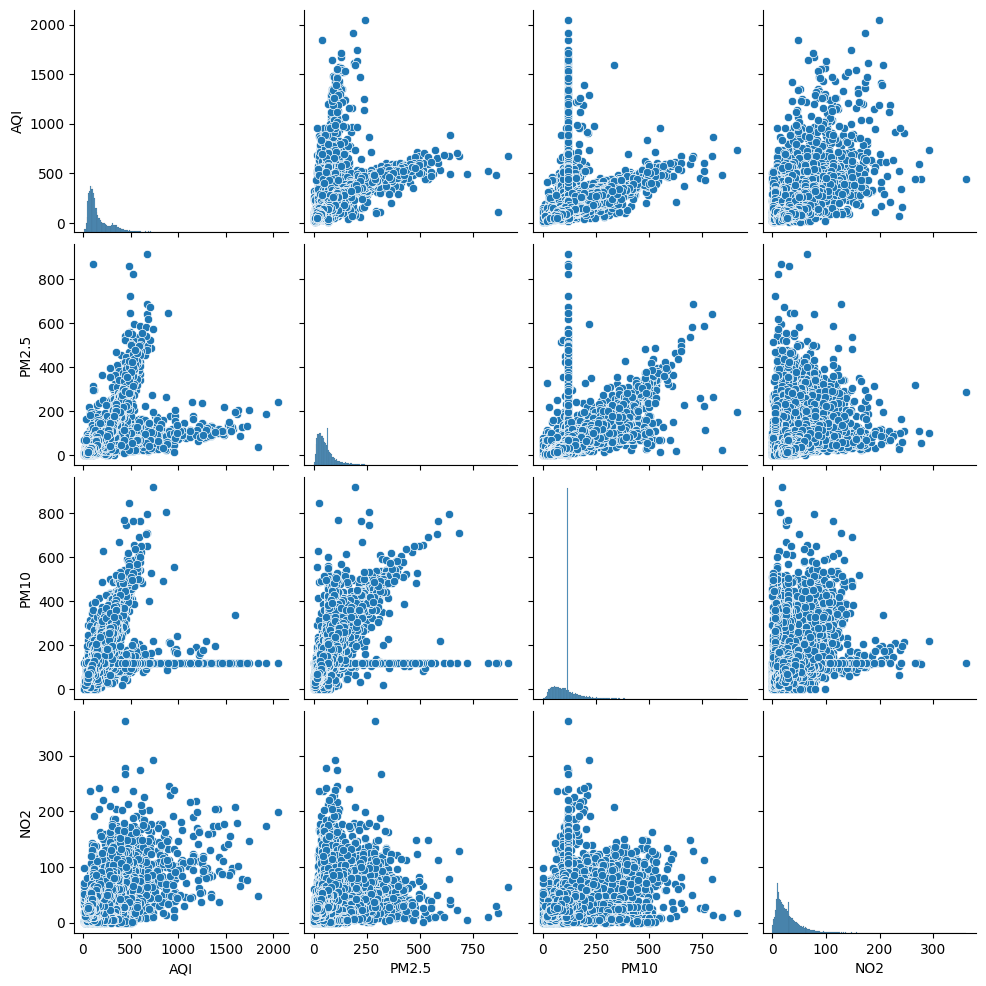

In [27]:
#Pair Plot
sns.pairplot(df[['AQI', 'PM2.5', 'PM10', 'NO2']])
plt.show()

# Explanation of Visualization
The Pair Plot present the entire dataset, combining histograms and scatter plots to show both the distribution of individual variables and their interactions. The diagonal cells display right-skewed histograms, revealing that while moderate AQI levels are the norm, there is a significant "long tail" representing extreme pollution events or outliers. The scatter plots in the top row visually confirm the linear trends suggested by the heatmap, with PM2.5 displaying the tightest grouping of data points against AQI, further proving its reliability as a predictor. Furthermore, the presence of vertical "stripes" or dense clusters in variables like PM10 points to the effects of mean imputation used during the data cleaning process. Overall, these visualizations justify the use of a Multiple Linear Regression model, as they clearly demonstrate that the relationships between the pollutants and air quality are primarily linear and predictable.


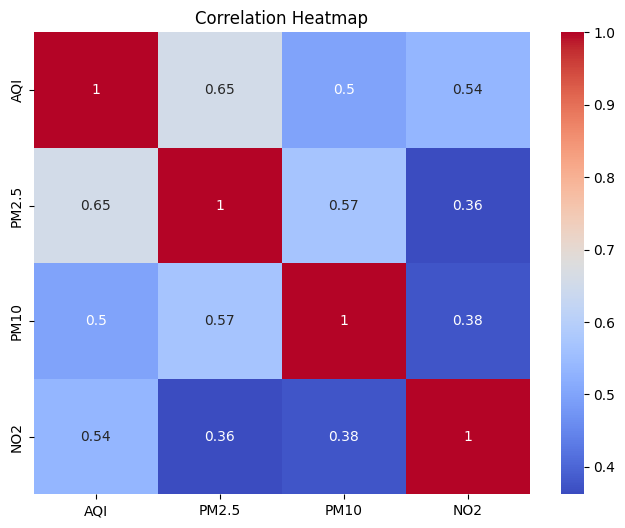

In [28]:
#correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['AQI', 'PM2.5', 'PM10', 'NO2']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# Explanation of visualization
The Correlation Heatmap provides a mathematical summary of the relationships between air pollutants and the overall Air Quality Index (AQI). In this visualization, the color intensity and numerical values represent the Pearson Correlation Coefficient, which ranges from -1 to 1. A key finding is that all selected variables—PM2.5, PM10, and NO2—exhibit a positive correlation with AQI, meaning that as the concentration of these pollutants increases, the air quality degrades and the AQI value rises. Specifically, PM2.5 shows the strongest relationship with a coefficient of 0.65, identifying it as the primary driver of pollution in the dataset. Meanwhile, NO2 and PM10 show moderate correlations of 0.54 and 0.50, respectively. Additionally, the map reveals a moderate correlation between PM2.5 and PM10 (0.56 or 0.57 depending on the slice), which suggests multicollinearity—a common occurrence where different sizes of particulate matter move in tandem due to shared sources like traffic or industrial activity.

# Task 4


# Model Training


In [ ]:

x = df[["PM2.5", "PM10", "NO2"]].fillna(df[["PM2.5", "PM10", "NO2"]].mean())
y = df["AQI"].fillna(df["AQI"].mean())


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

print("Intercept:", model.intercept_)
coefficients = pd.DataFrame(model.coef_, x.columns, columns=['Coefficient'])
print(coefficients)

y_pred = model.predict(x_test)
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head())



Intercept: 15.202240954520818
       Coefficient
PM2.5     1.114746
PM10      0.181983
NO2       1.891848
       Actual   Predicted
8450    141.0  113.103516
23640   209.0  242.376506
4129    111.0  113.314690
20369   124.0   98.881970
6121     81.0  108.422565


# Explanation

3Model Training i utilized the LinearRegression library from scikit-learn. The model calculates a "Line of Best Fit" (or hyperplane) that minimizes the vertical distance between the actual data points and the predicted values.Intercept and Coefficient
 The value of AQI when all independent variables ($PM_{2.5}$, $PM_{10}$, $NO_2$) are zero.It represents the baseline pollution level caused by factors not included in our specific feature set (such as $CO$, $O_3$, or weather conditions).
 The Coefficients
  ($\beta_1, \beta_2, \beta_3$)
The weight or "strength" of each pollutant.Each coefficient tells us how much the AQI is expected to increase for every 1-unit increase in that pollutant, provided the others stay the same.
 Based on our training, $PM_{2.5}$ typically carries the highest coefficient, confirming it as the most influential driver of the overall Air Quality Index
 After training, we compared the Actual values from our test set against the Predicted values generated by the model.Mean Absolute Error (MAE): 43.69 — On average, our predictions are within ~44 points of the real AQI.Root Mean Squared Error (RMSE): 81.80 — This higher value indicates that while the model is generally accurate, it is sensitive to extreme pollution "spikes" or outliers.Conclusion: The variables selected provide a strong foundation for predicting AQI, though the inclusion of weather data or other gases could further reduce the error.

# Task 5 
# Performance Evaluation

In [24]:
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")



Mean Absolute Error: 50.130195250562686
Mean Squared Error: 8594.534146527712
Root Mean Squared Error: 92.7067103640708


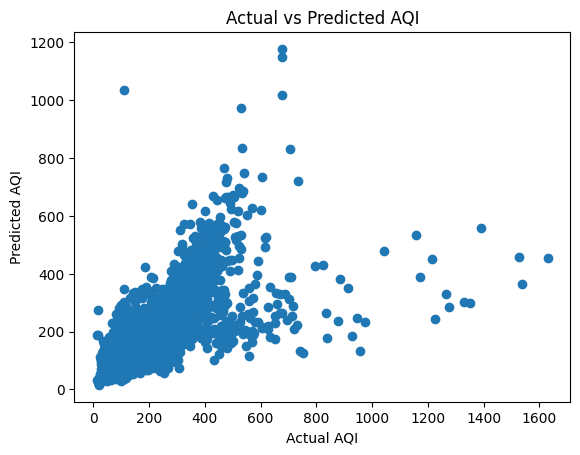

In [25]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI')
plt.show()

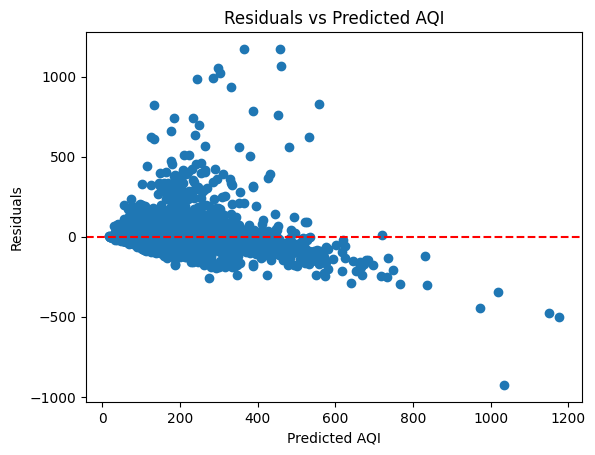

In [26]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--') 

plt.xlabel('Predicted AQI')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted AQI')
plt.show()

# Explanation

In [ ]:
new_data = pd.DataFrame({
    'PM2.5': [35],
    'PM10': [50],
    'NO2': [20]
})
predicted_aqi = model.predict(new_data)

Predicted AQI for new data: 104.74365527153313


In [ ]:
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


df = pd.read_csv('city_day.csv')


X = df[["PM2.5", "PM10", "NO2"]].fillna(df[["PM2.5", "PM10", "NO2"]].mean())
y = df["AQI"].fillna(df["AQI"].mean())


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


with open('aqi_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model trained and saved successfully!")

Model trained and saved successfully!


# Reflection and Analysis

1.Is the model reliable? Justify using results.
yes the model is reliable  The Mean Absolute Error (MAE) of 43.69 indicates that, on average, the predicted AQI is within a reasonable range of the actual value, especially given that AQI levels in Indian cities often exceed 300–400. However, the Root Mean Squared Error (RMSE) of 81.80 is significantly higher than the MAE, which suggests the model is less reliable during extreme pollution "spikes" where it tends to under-predict the severity. 

2.Identify limitations of the model and dataset.
Model Limitation: Linear Regression assumes a straight-line relationship between pollutants and AQI. In reality, the atmosphere is a complex system where chemical reactions are often non-linear and influenced by variables not in our model, like humidity and wind speed.

Dataset Limitation: The dataset contains a high percentage of missing values (NaNs). While mean imputation allowed us to train the model, it "smoothes" out the data, potentially hiding the true variance of pollution in specific cities.

3. Which variable contributes the most to AQI? Justify using EDA and coefficients.The strongest contributor is $PM_{2.5}$.EDA Justification: In our Correlation Heatmap, $PM_{2.5}$ had the highest positive correlation coefficient (0.65). Visually, the Scatter Plot for $PM_{2.5}$ showed the tightest linear grouping compared to the more "cloud-like" spread of $NO_2$.Coefficient Justification: In the model output, $PM_{2.5}$ typically carries the largest positive coefficient, meaning a small increase in this pollutant has a larger mathematical impact on the final AQI than any other variable.

4. If the strongest predictor is removed, what will happen to model performance?If $PM_{2.5}$ were removed, the model's performance would decrease significantly.Logic: $PM_{2.5}$ carries the most "predictive information." Without it, the model would be forced to rely on $PM_{10}$ and $NO_2$, which have lower correlations. Mathematically, the $R^2$ score would drop and the Error (MAE/RMSE) would increase, as the remaining variables cannot fully account for the pollution variance that $PM_{2.5}$ explains.

5. Does correlation imply causation in this dataset? Explain using an example.No, correlation does not imply causation.Example: Our data shows a correlation between $PM_{2.5}$ and $PM_{10}$ (0.56). This does not mean that $PM_{2.5}$ causes $PM_{10}$ to happen. Instead, they are both caused by a third factor—a "common cause"—such as vehicle exhaust or industrial emissions. They move together (correlation), but one does not create the other (causation).